 # 🎮 Video Game Sales Prediction with Machine Learning



 ## Project Overview



 Predict total video game sales using information available before release.



 Workflow:

 - Exploratory Data Analysis (EDA)

 - Data Cleaning

 - Feature Engineering

 - Train/Test Split

 - Linear Regression

 - Log Transformation

 - Random Forest

 - Feature Importance

 - Conclusions

 # 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


 # 2. Loading the Dataset

In [2]:
games_df = pd.read_csv("Data_sets\\Videojuegos\\vgchartz-2024.csv")


 # 3. Exploratory Data Analysis (EDA)

In [3]:
games_df.head()


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [4]:
print(games_df.shape)
print(games_df.dtypes)
print(games_df.isna().sum())


(64016, 14)
img                 str
title               str
console             str
genre               str
publisher           str
developer           str
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date        str
last_update         str
dtype: object
img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


 # 4. Data Cleaning & Feature Engineering

In [5]:
training_df = games_df.drop(columns=[
    "img","critic_score","na_sales","jp_sales","pal_sales",
    "other_sales","last_update","title","publisher","developer"
])

training_df = training_df.dropna()

training_df["release_date"] = pd.to_datetime(training_df["release_date"])
training_df["release_year"] = training_df["release_date"].dt.year
training_df["release_month"] = training_df["release_date"].dt.month
training_df = training_df.drop(columns=["release_date"])

training_df = pd.get_dummies(
    training_df,
    columns=["console","genre"],
    dtype=int
)

training_df.head()


,total_sales,release_year,release_month,console_2600,console_3DO,console_3DS,console_DC,console_DS,console_GB,console_GBA,...,genre_Platform,genre_Puzzle,genre_Racing,genre_Role-Playing,genre_Sandbox,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel
0,20.32,2013,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,19.39,2014,11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16.15,2002,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15.86,2013,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,15.09,2015,11,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


 # 5. Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X = training_df.drop(columns=["total_sales"])
y = training_df["total_sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


 # 6. Baseline Model — Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
}, index=y_test.index)

mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae:.3f}")


MAE: 0.361


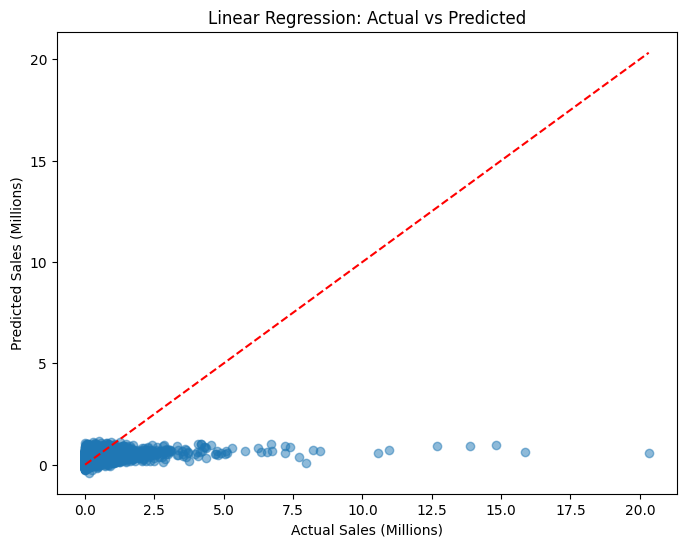

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Actual Sales (Millions)")
plt.ylabel("Predicted Sales (Millions)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


 ## 6.1 Target Distribution

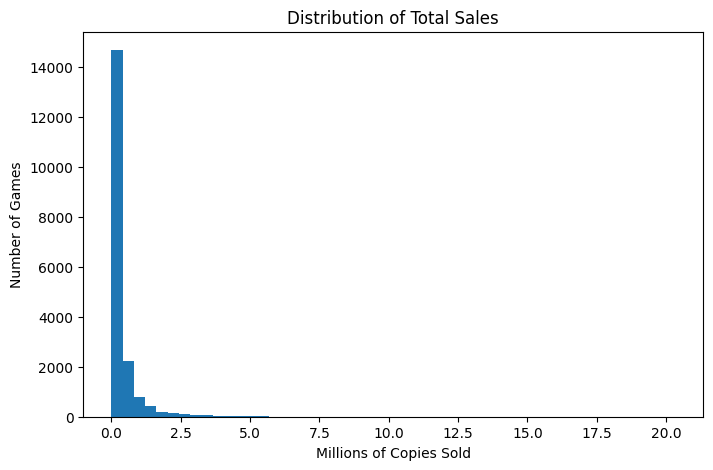

In [9]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=50)
plt.title("Distribution of Total Sales")
plt.xlabel("Millions of Copies Sold")
plt.ylabel("Number of Games")
plt.show()


 # 7. Linear Regression with Log Transformation

In [10]:
y_train_log = np.log1p(y_train)

model = LinearRegression()
model.fit(X_train, y_train_log)

log_predictions = model.predict(X_test)
predictions = np.expm1(log_predictions)

mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae:.3f}")


MAE: 0.316


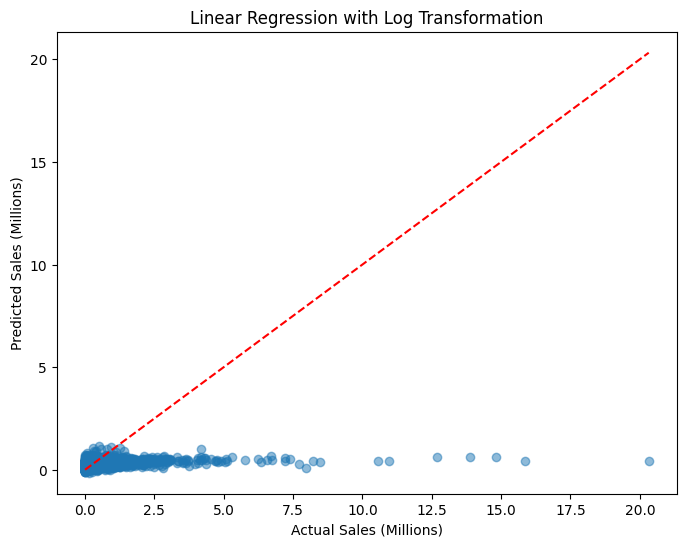

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Actual Sales (Millions)")
plt.ylabel("Predicted Sales (Millions)")
plt.title("Linear Regression with Log Transformation")
plt.show()


 # 8. Random Forest Regressor

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")


MAE: 0.369
R²: -0.019


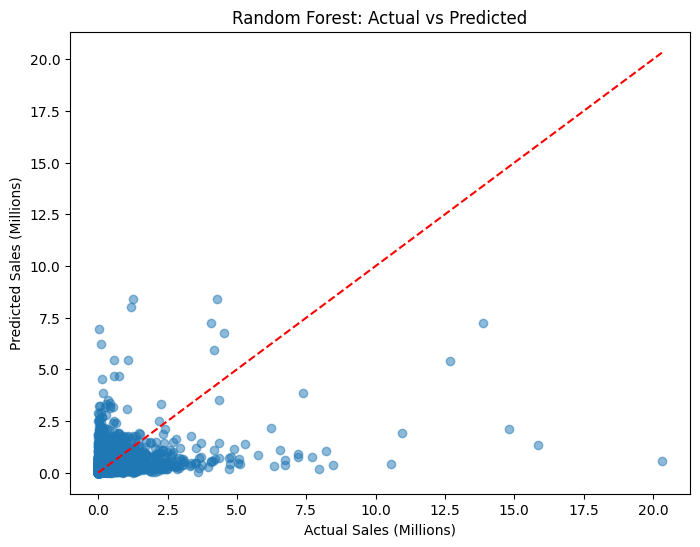

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Actual Sales (Millions)")
plt.ylabel("Predicted Sales (Millions)")
plt.title("Random Forest: Actual vs Predicted")
plt.show()


 ## 8.1 Feature Importance

In [14]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(10)

print(top_features)


          Feature  Importance
0    release_year    0.362713
1   release_month    0.303686
24    console_PS3    0.035653
25    console_PS4    0.035346
37   console_X360    0.035219
41   genre_Action    0.030990
56  genre_Shooter    0.024801
58   genre_Sports    0.021145
23    console_PS2    0.014011
48     genre_Misc    0.012612


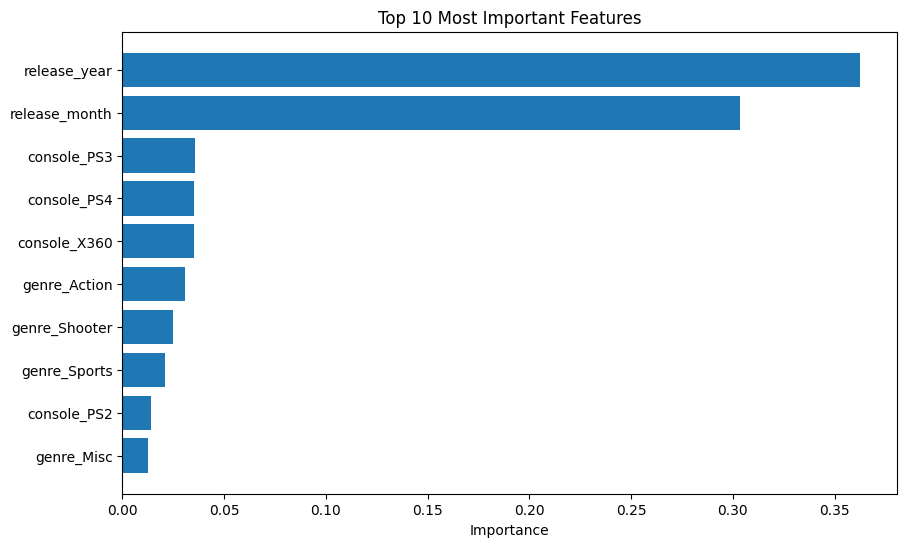

In [15]:
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()


 # 9. Conclusions



 - Linear Regression establishes the baseline.

 - Log transformation improves MAE.

 - Random Forest captures nonlinear patterns but does not improve MAE.

 - Future work: Frequency Encoding, Target Encoding, XGBoost, CatBoost.